<center>
<h1>Passenger Traffic Classification at SFO: A 23-Year Machine Learning Analysis</h1>

<h3>Andrew Hashoush, Christopher Guillen, and Dana Neuman</h3>

<h4>April 13th, 2026</h4>
</center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/Air_Traffic_Passenger_Statistics.csv")

df.head()

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM


# Data Preprocessing

In [3]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# convert date
df["activity_period"] = pd.to_datetime(df["activity_period"].astype(str), format="%Y%m")
df = df.dropna(subset=["activity_period"])

df["year"] = df["activity_period"].dt.year
df["month"] = df["activity_period"].dt.month

# sort by time for time split, chronological sort ensures no future data leaks into training data
df = df.sort_values("activity_period")

df.info()

<class 'pandas.DataFrame'>
Index: 39588 entries, 0 to 39587
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   activity_period              39588 non-null  datetime64[us]
 1   activity_period_start_date   39588 non-null  str           
 2   operating_airline            39588 non-null  str           
 3   operating_airline_iata_code  39272 non-null  str           
 4   published_airline            39588 non-null  str           
 5   published_airline_iata_code  39272 non-null  str           
 6   geo_summary                  39588 non-null  str           
 7   geo_region                   39588 non-null  str           
 8   activity_type_code           39588 non-null  str           
 9   price_category_code          39588 non-null  str           
 10  terminal                     39588 non-null  str           
 11  boarding_area                39588 non-null  str         

In [4]:
# checking for dupilcate rows
print("Duplicates:", df.duplicated().sum())
#checking for missing values across columns
print("\nMissing values per column:", df.isnull().sum())

Duplicates: 0

Missing values per column: activity_period                  0
activity_period_start_date       0
operating_airline                0
operating_airline_iata_code    316
published_airline                0
published_airline_iata_code    316
geo_summary                      0
geo_region                       0
activity_type_code               0
price_category_code              0
terminal                         0
boarding_area                    0
passenger_count                  0
data_as_of                       0
data_loaded_at                   0
year                             0
month                            0
dtype: int64


In [5]:
#dropping obvious insignifcant columns or redundant columns
df = df.drop(["operating_airline_iata_code", "published_airline_iata_code", "activity_period_start_date", "data_as_of",
                    "data_loaded_at"], axis=1, errors='ignore')
df.info()

<class 'pandas.DataFrame'>
Index: 39588 entries, 0 to 39587
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   activity_period      39588 non-null  datetime64[us]
 1   operating_airline    39588 non-null  str           
 2   published_airline    39588 non-null  str           
 3   geo_summary          39588 non-null  str           
 4   geo_region           39588 non-null  str           
 5   activity_type_code   39588 non-null  str           
 6   price_category_code  39588 non-null  str           
 7   terminal             39588 non-null  str           
 8   boarding_area        39588 non-null  str           
 9   passenger_count      39588 non-null  int64         
 10  year                 39588 non-null  int32         
 11  month                39588 non-null  int32         
dtypes: datetime64[us](1), int32(2), int64(1), str(8)
memory usage: 3.6 MB


# Exploratory Data Analysis (EDA)

In [6]:
df.describe(include='all')

,activity_period,operating_airline,published_airline,geo_summary,geo_region,activity_type_code,price_category_code,terminal,boarding_area,passenger_count,year,month
count,39588,39588,39588,39588,39588,39588,39588,39588,39588,39588.000000,39588.000000,39588.000000
unique,NaN,138,124,2,9,3,2,5,8,NaN,NaN,NaN
top,NaN,United Airlines,United Airlines,International,US,Enplaned,Other,International,A,NaN,NaN,NaN
freq,NaN,4549,5241,25870,13718,18795,35431,24677,14204,NaN,NaN,NaN
mean,2013-07-24 19:42:21.497423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27777.799510,2013.099702,6.567824
min,1999-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1999.000000,1.000000
25%,2006-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4335.750000,2006.000000,4.000000
50%,2014-02-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8572.000000,2014.000000,7.000000
75%,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19566.000000,2020.000000,10.000000
max,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,856501.000000,2026.000000,12.000000


### Passenger Count Distribution

The original histogram revealed a heavily right skewed distribution. A log scale 
transformation was applied to better reveal the underlying shape. On a log scale, 
each step on the x-axis represents a value 10 times larger than the previous 
(1, 10, 100, 1,000, 10,000, 100,000), making it easier to visualize data with 
a very wide range of values.

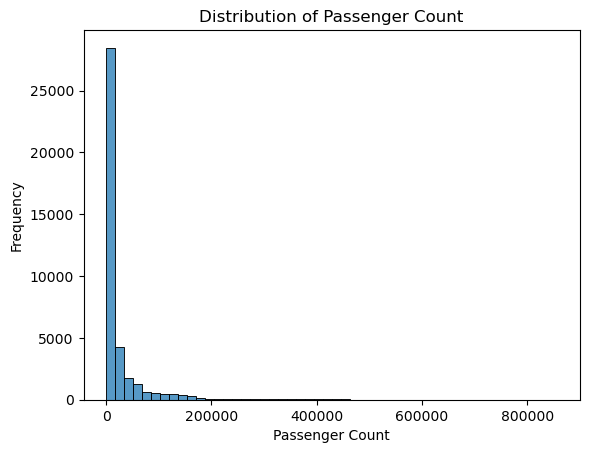

In [7]:
# Original Distribution
sns.histplot(df["passenger_count"], bins=50)
plt.title("Distribution of Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.show()

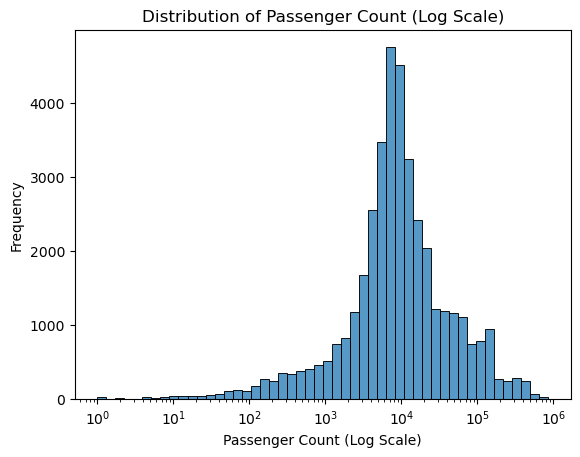

In [8]:
# the original histogram reflects a right skewed distribution with high density at lower counts
# a log scale transformation was applied to better reveal the underlying distribution shape
# the log scale distribution approximates a normal distribution, centered around 10,000 passengers
sns.histplot(df["passenger_count"], bins=50, log_scale=True)
plt.title("Distribution of Passenger Count (Log Scale)")
plt.xlabel("Passenger Count (Log Scale)")
plt.ylabel("Frequency")
plt.show()

### Passenger Trends Over Time

#### By Year

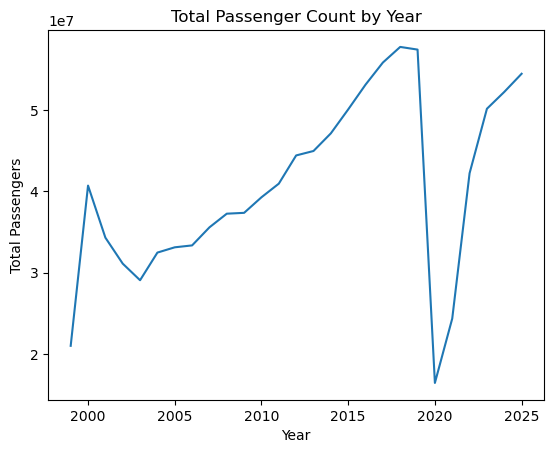

In [9]:
# Totaling passenger count by year
# 2026 shows incomplete data, which takes out the sharp drop
year = df[df["year"] < 2026].groupby("year")["passenger_count"].sum()

year.plot()
plt.title("Total Passenger Count by Year")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.show()

#### By Month

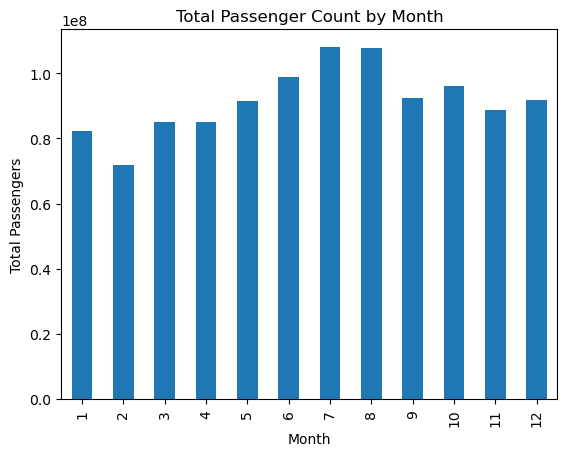

In [10]:
month = df.groupby('month')['passenger_count'].sum()

month.plot(kind='bar')
plt.title("Total Passenger Count by Month")
plt.xlabel("Month")
plt.ylabel("Total Passengers")
plt.show()

### Traffic by Airline

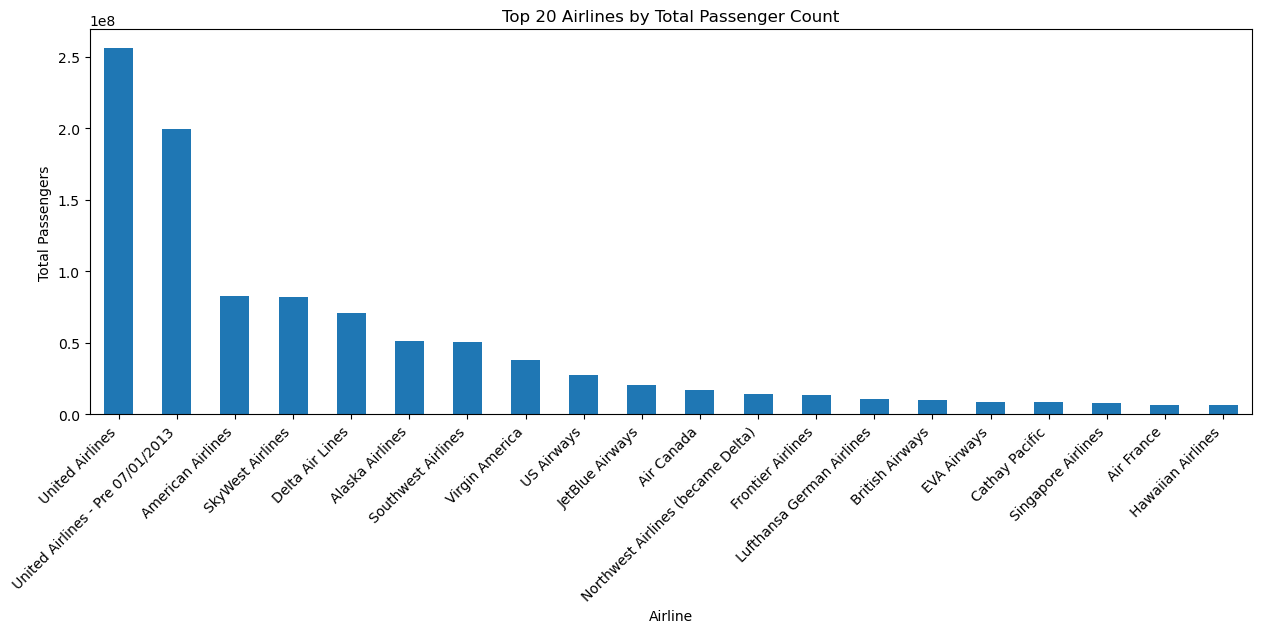

In [11]:
# total passenger count by airline, identifying which airlines dominate SFO traffic
airlines = df.groupby("operating_airline")["passenger_count"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(15,5))
airlines.plot(kind='bar')
plt.title('Top 20 Airlines by Total Passenger Count')
plt.xlabel('Airline')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Passengers')
plt.show()

### Traffic by Terminal

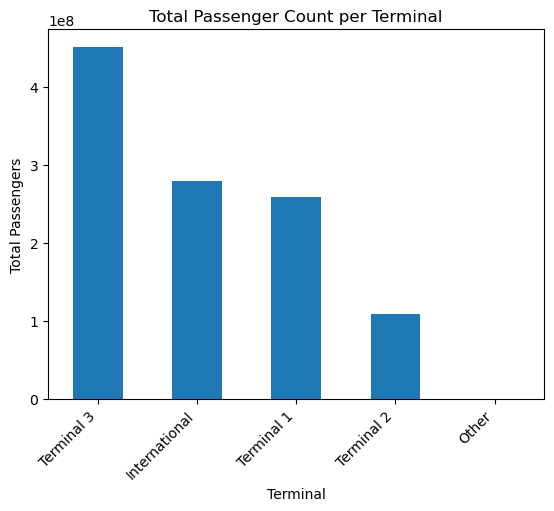

In [12]:
terminal = df.groupby('terminal')['passenger_count'].sum().sort_values(ascending=False)

terminal.plot(kind='bar')
plt.title("Total Passenger Count per Terminal")
plt.xlabel("Terminal")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45, ha='right')
plt.show()

### Traffic by Geographic Region

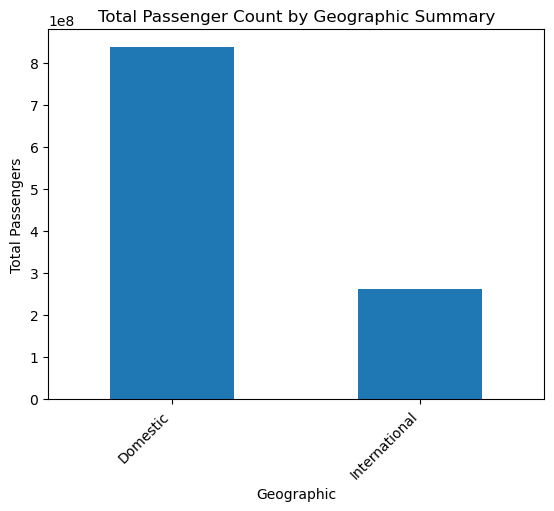

In [13]:
geo = df.groupby('geo_summary')['passenger_count'].sum().sort_values(ascending=False)

geo.plot(kind='bar')
plt.title("Total Passenger Count by Geographic Summary")
plt.xlabel("Geographic")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45, ha='right')
plt.show()

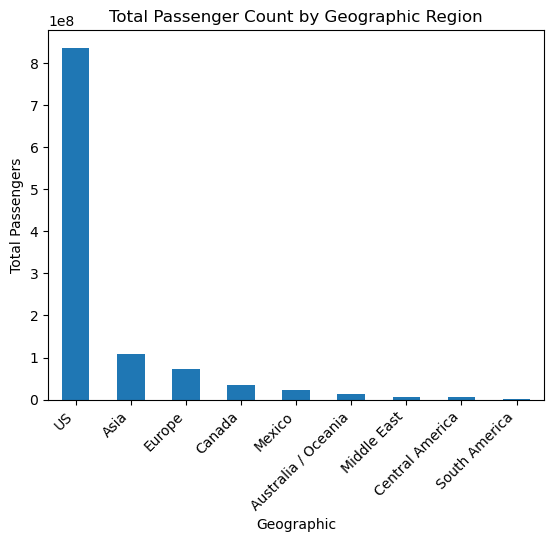

In [14]:
region = df.groupby('geo_region')['passenger_count'].sum().sort_values(ascending=False)

region.plot(kind='bar')
plt.title("Total Passenger Count by Geographic Region")
plt.xlabel("Geographic")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45, ha='right')
plt.show()

### Activity Type Distribution

Activity type was examined and found to be nearly equally distributed between 
enplaned and deplaned passengers, with transit representing only a small portion
of records. This variable seems to have limited predictive value for traffic level 
classification.

In [15]:
print(df["activity_type_code"].value_counts())

activity_type_code
Enplaned          18795
Deplaned          18486
Thru / Transit     2307
Name: count, dtype: int64


# Target Variable Definition

In [16]:
# threshold top 25% - justified by EDA showing right skewed distribution
# top quartile represents meaningfully high traffic at SFO
threshold = df["passenger_count"].quantile(0.75)
df["traffic_level"] = np.where(df["passenger_count"] >= threshold, "High", "Low")

### Stacked and normalized charts

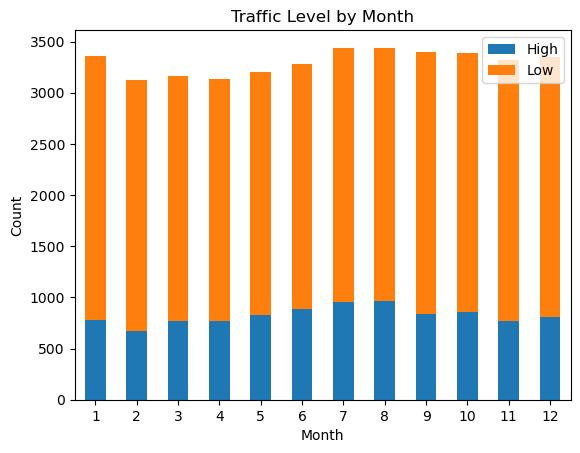

In [17]:
# stacked bar chart of month per low and high traffic levels
crosstab_month = pd.crosstab(df["month"], df["traffic_level"])
crosstab_month.plot(kind='bar', stacked=True)
plt.title("Traffic Level by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

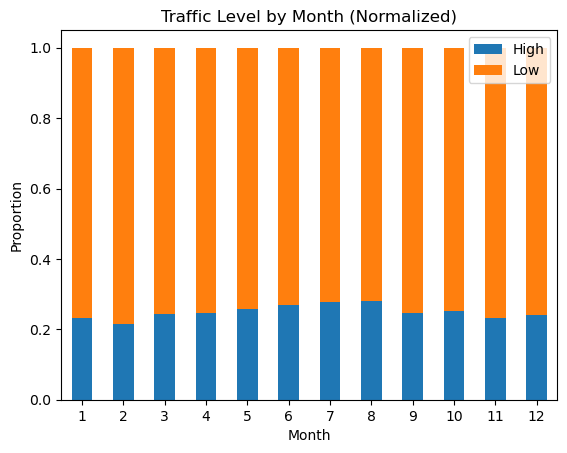

In [18]:
# normalized bar chart, exploring relationship between month and traffic level
crosstab_month = pd.crosstab(df["month"], df["traffic_level"])
crosstab_norm = crosstab_month.div(crosstab_month.sum(axis=1), axis=0)

crosstab_norm.plot(kind='bar', stacked=True)
plt.title("Traffic Level by Month (Normalized)")
plt.xlabel("Month")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

# Train/Test Split

In [19]:
# chronological train/test split, 80% train, 20% test
# training the model on historical data to prevent data leakage
split_date = df["activity_period"].quantile(0.8)

train = df[df["activity_period"] < split_date]
test = df[df["activity_period"] >= split_date]

# define independent variables (features) and dependent variable (target)
X_train = train.drop(["traffic_level", "passenger_count", "activity_period", "published_airline", "activity_type_code", "boarding_area"], axis=1)
y_train = train["traffic_level"]

X_test = test.drop(["traffic_level", "passenger_count", "activity_period", "published_airline", "activity_type_code", "boarding_area"], axis=1)
y_test = test["traffic_level"]

### Split Validation

In [20]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [21]:
X_train.head()

,year,month,operating_airline_ATA Airlines,"operating_airline_Aer Lingus, Ltd.",operating_airline_Aeroflot Russian International Airlines,operating_airline_Aeromexico,operating_airline_Air 2000,operating_airline_Air Atlanta Icelandic,operating_airline_Air Berlin,operating_airline_Air Canada,...,geo_region_Europe,geo_region_Mexico,geo_region_Middle East,geo_region_South America,geo_region_US,price_category_code_Other,terminal_Other,terminal_Terminal 1,terminal_Terminal 2,terminal_Terminal 3
0,1999,7,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
101,1999,7,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
100,1999,7,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
98,1999,7,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False
97,1999,7,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False


In [22]:
df["traffic_level"].value_counts()

traffic_level
Low     29690
High     9898
Name: count, dtype: int64

In [23]:
print(X_train.shape, X_test.shape)

(31580, 140) (8008, 140)


In [24]:
print("Train max date:", train["activity_period"].max())
print("Test min date:", test["activity_period"].min())

Train max date: 2021-08-01 00:00:00
Test min date: 2021-09-01 00:00:00


In [25]:
df["activity_period"].unique()[:10]

<DatetimeArray>
['1999-07-01 00:00:00', '1999-08-01 00:00:00', '1999-09-01 00:00:00',
 '1999-10-01 00:00:00', '1999-11-01 00:00:00', '1999-12-01 00:00:00',
 '2000-01-01 00:00:00', '2000-02-01 00:00:00', '2000-03-01 00:00:00',
 '2000-04-01 00:00:00']
Length: 10, dtype: datetime64[us]

# Modeling

In [26]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Intercept:", log_model.intercept_[0])
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.head(5))
print(coef_df.tail(5))

Intercept: 0.027934444866507663
                                    Feature  Coefficient
128                       geo_region_Canada     4.849888
58      operating_airline_Hawaiian Airlines     4.649204
101  operating_airline_Sun Country Airlines     4.454800
127          geo_region_Australia / Oceania     3.921351
60            operating_airline_Horizon Air     3.478025
                                 Feature  Coefficient
47     operating_airline_Delta Air Lines    -3.752346
115    operating_airline_United Airlines    -3.783948
25   operating_airline_American Airlines    -5.886285
114         operating_airline_US Airways    -6.479132
9           operating_airline_Air Canada    -8.115022


In [27]:
# predictions
y_pred_log = log_model.predict(X_test)

# evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.843031968031968

Classification Report:

              precision    recall  f1-score   support

        High       0.64      0.66      0.65      1787
         Low       0.90      0.90      0.90      6221

    accuracy                           0.84      8008
   macro avg       0.77      0.78      0.78      8008
weighted avg       0.84      0.84      0.84      8008


Confusion Matrix:

[[1180  607]
 [ 650 5571]]


['High' 'High' 'Low' ... 'High' 'High' 'Low']


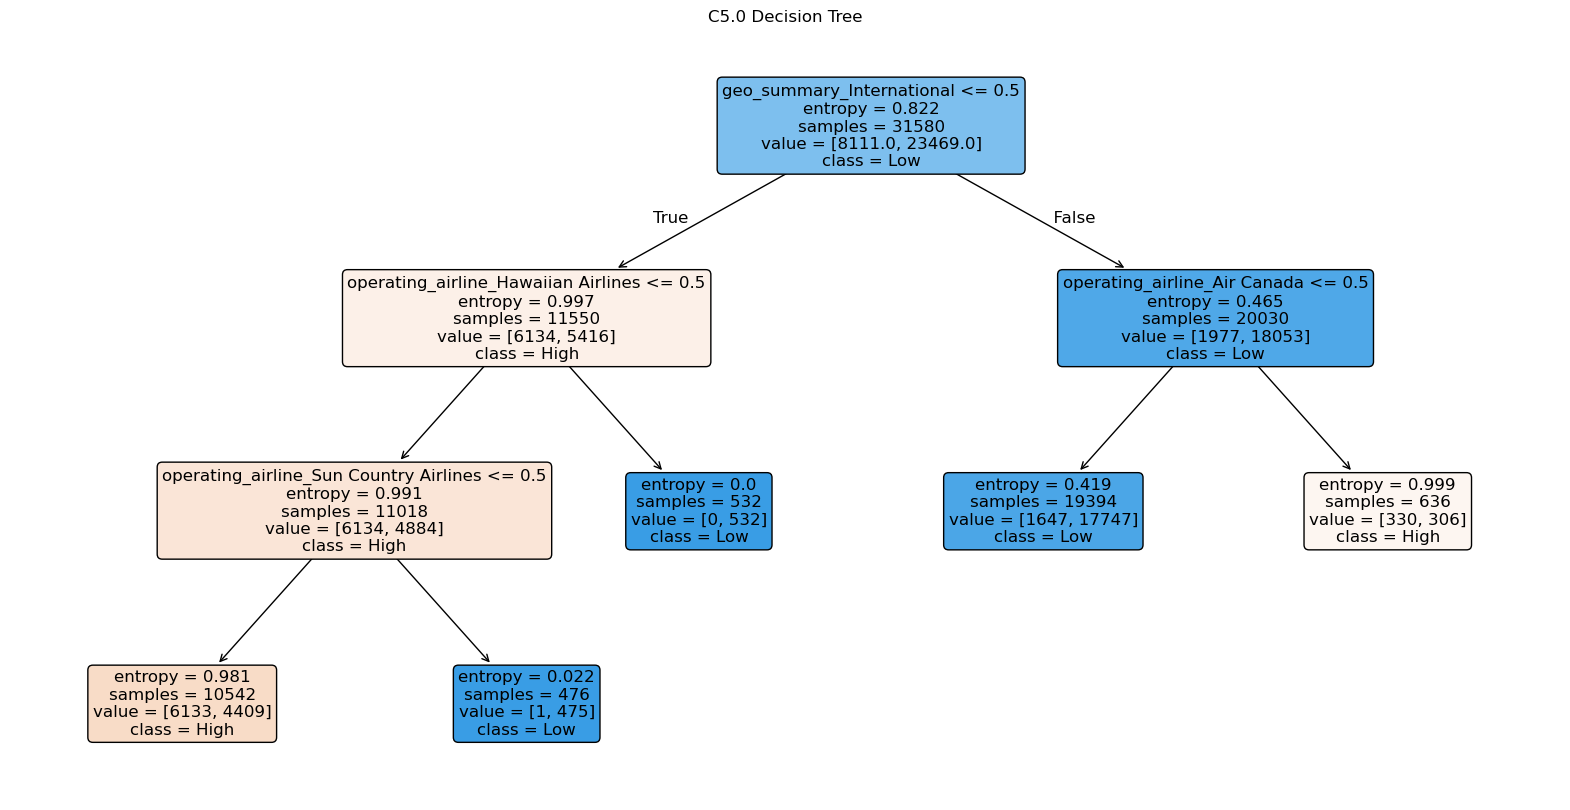

In [39]:
# C5.0 model, entropy criterion 
c5_model = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=5, min_samples_leaf=75, random_state=42).fit(X_train, y_train)

# predictions
y_pred_c5 = c5_model.predict(X_test)
print(y_pred_c5)

# visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(c5_model,
          feature_names=X_train.columns.tolist(),
          class_names=y_train.unique(),
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("C5.0 Decision Tree")
plt.show()

In [40]:
# C5 evaluation
print("C5.0 Accuracy:", accuracy_score(y_test, y_pred_c5))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_c5))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_c5))

C5.0 Accuracy: 0.84502997002997

Classification Report:

              precision    recall  f1-score   support

        High       0.63      0.73      0.68      1787
         Low       0.92      0.88      0.90      6221

    accuracy                           0.85      8008
   macro avg       0.78      0.80      0.79      8008
weighted avg       0.86      0.85      0.85      8008


Confusion Matrix:

[[1308  479]
 [ 762 5459]]


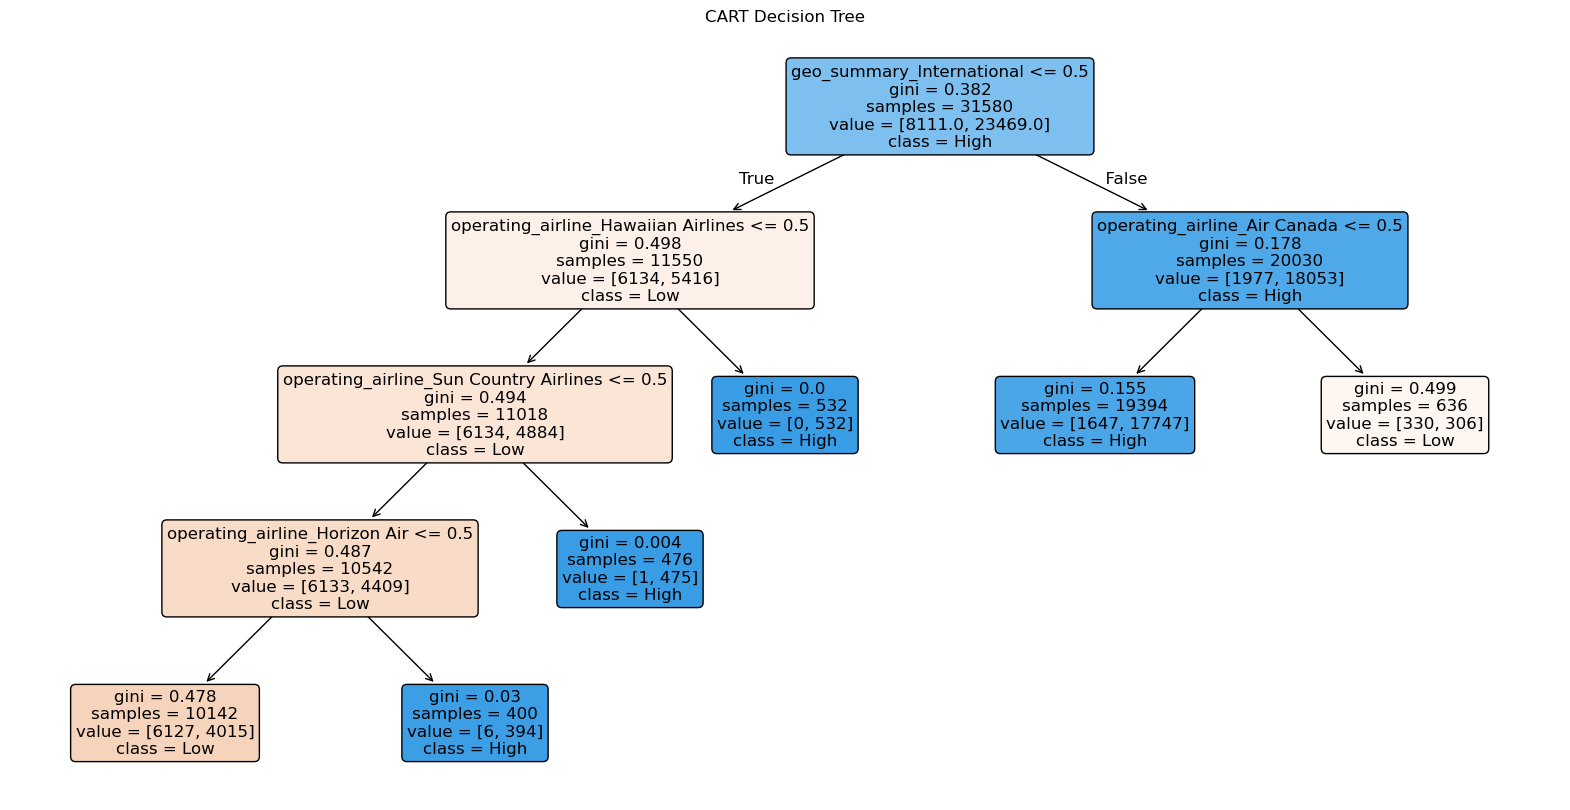

In [37]:
# CART model, gini index criterion
cart_model = DecisionTreeClassifier(criterion='gini', max_leaf_nodes=6, random_state=42)
cart_model.fit(X_train, y_train)

# predictions
y_pred_cart = cart_model.predict(X_test)

# visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(cart_model,
          feature_names=X_train.columns.tolist(),
          class_names=["Low", "High"],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("CART Decision Tree")
plt.show()


In [41]:
# CART evaluation
print("CART Accuracy:", accuracy_score(y_test, y_pred_cart))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_cart))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_cart))

CART Accuracy: 0.8535214785214785

Classification Report:

              precision    recall  f1-score   support

        High       0.66      0.72      0.69      1787
         Low       0.92      0.89      0.90      6221

    accuracy                           0.85      8008
   macro avg       0.79      0.81      0.80      8008
weighted avg       0.86      0.85      0.86      8008


Confusion Matrix:

[[1288  499]
 [ 674 5547]]


In [32]:
# Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# predictions
y_pred_rf = rf_model.predict(X_test)

# evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8631368631368631

Classification Report:

              precision    recall  f1-score   support

        High       0.78      0.53      0.64      1787
         Low       0.88      0.96      0.92      6221

    accuracy                           0.86      8008
   macro avg       0.83      0.75      0.78      8008
weighted avg       0.86      0.86      0.85      8008


Confusion Matrix:

[[ 954  833]
 [ 263 5958]]


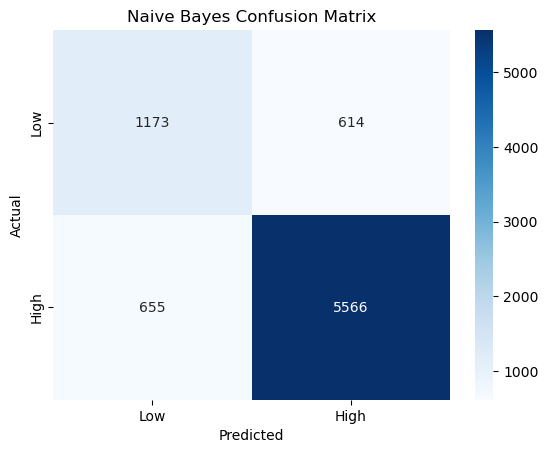

Predicted  High   Low  Total
Actual                      
High       1173   614   1787
Low         655  5566   6221
Total      1828  6180   8008


In [33]:
# Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# predictions
y_pred_nb = nb_model.predict(X_test)

# confusion matrix heatmap
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# confusion matrix chart
ypred_nb = pd.crosstab(y_test, y_pred_nb,
                       rownames=['Actual'], colnames=['Predicted'])
ypred_nb['Total'] = ypred_nb.sum(axis=1)
ypred_nb.loc['Total'] = ypred_nb.sum()
print(ypred_nb)


In [42]:
# evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8415334665334665

Classification Report:

              precision    recall  f1-score   support

        High       0.64      0.66      0.65      1787
         Low       0.90      0.89      0.90      6221

    accuracy                           0.84      8008
   macro avg       0.77      0.78      0.77      8008
weighted avg       0.84      0.84      0.84      8008


Confusion Matrix:

[[1173  614]
 [ 655 5566]]


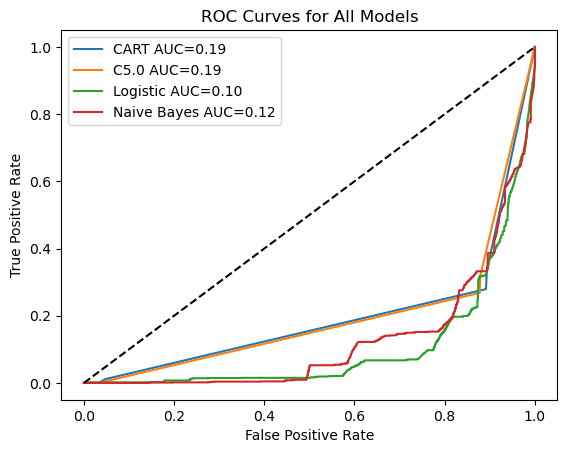

In [44]:
# get predicted probabilities for each model
y_prob_cart = cart_model.predict_proba(X_test)[:, 1]
y_prob_c5 = c5_model.predict_proba(X_test)[:, 1]
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# encode y_test to numeric
y_test_encoded = (y_test == "High").astype(int)

# ROC Curves
fpr_cart, tpr_cart, _ = roc_curve(y_test_encoded, y_prob_cart)
fpr_c5, tpr_c5, _ = roc_curve(y_test_encoded, y_prob_c5)
fpr_log, tpr_log, _ = roc_curve(y_test_encoded, y_prob_log)
fpr_nb, tpr_nb, _ = roc_curve(y_test_encoded, y_prob_nb)

# plot
plt.plot(fpr_cart, tpr_cart, label=f'CART AUC={roc_auc_score(y_test_encoded, y_prob_cart):.2f}')
plt.plot(fpr_c5, tpr_c5, label=f'C5.0 AUC={roc_auc_score(y_test_encoded, y_prob_c5):.2f}')
plt.plot(fpr_log, tpr_log, label=f'Logistic AUC={roc_auc_score(y_test_encoded, y_prob_log):.2f}')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes AUC={roc_auc_score(y_test_encoded, y_prob_nb):.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [45]:
def get_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]
    GT = TN + FP + FN + TP
    
    accuracy = (TP + TN) / GT
    error_rate = 1 - accuracy
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    precision = TP / (TP + FP)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    
    return {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Error Rate': round(error_rate, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'Precision': round(precision, 4),
        'F1': round(f1, 4)
    }

# build comparison table
results = pd.DataFrame([
    get_metrics(y_test, y_pred_cart, 'CART'),
    get_metrics(y_test, y_pred_c5, 'C5.0'),
    get_metrics(y_test, y_pred_log, 'Logistic Regression'),
    get_metrics(y_test, y_pred_nb, 'Naive Bayes'),
    get_metrics(y_test, y_pred_rf, 'Random Forest')
])

results.set_index('Model')

,Accuracy,Error Rate,Sensitivity,Specificity,Precision,F1
Model,,,,,,
CART,0.8535,0.1465,0.8917,0.7208,0.9175,0.9044
C5.0,0.8450,0.1550,0.8775,0.7320,0.9193,0.8979
Logistic Regression,0.8430,0.1570,0.8955,0.6603,0.9017,0.8986
Naive Bayes,0.8415,0.1585,0.8947,0.6564,0.9006,0.8977
Random Forest,0.8631,0.1369,0.9577,0.5339,0.8773,0.9158
